In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer

from imblearn.combine import SMOTEENN

from pycaret.regression import *
from pycaret.internal.preprocess.transformers import TransformerWrapper

import joblib # For store the PowerTrasnformers

### Innits


In [14]:
## GK
## ---> >60  = 2
## ---> cs*4
## ---> ((sv)/3)*1
## ---> gc
## ---> yc*-1


## DEF
## ---> >60  = 2
## ---> xg*6
## ---> xa*3
## ---> cs*4
## ---> gc
## ---> yc*-1


## MID
## ---> >60  = +2
## ---> xg*5
## ---> xa*3
## ---> cs*1
## ---> yc*-1


## FWD
## ---> >60  = 2
## ---> xg*4
## ---> xa*3
## ---> yc*-1

In [15]:
gw=35

data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv') #.dropna()

data_tar = data_23_24[data_23_24['event']==gw]
data = data_23_24[data_23_24['event'] < gw]
data_test = data_23_24[data_23_24['event'] > gw]


data_36 = data_test[data_test['event'] == 36]
data_37 = data_test[data_test['event'] == 37]
data_38 = data_test[data_test['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

In [16]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Goals


## Def


In [17]:
def_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

xG
0.000000    1250
0.077296       1
0.638376       1
0.405012       1
0.017859       1
            ... 
0.861224       1
0.318866       1
0.470325       1
0.153211       1
0.102933       1
Name: count, Length: 752, dtype: int64


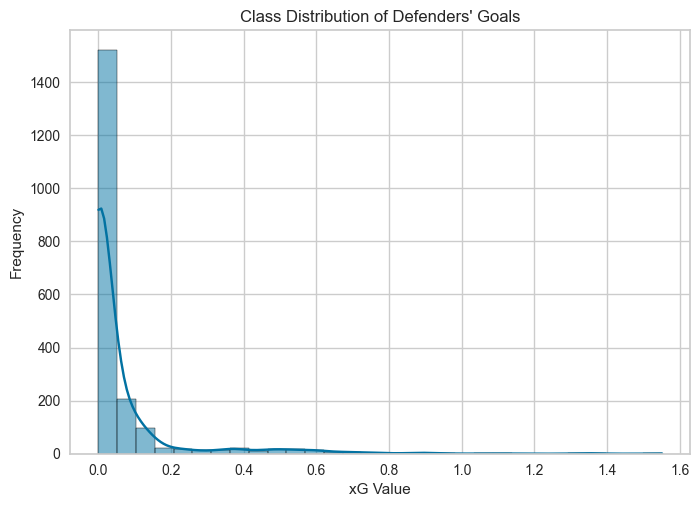

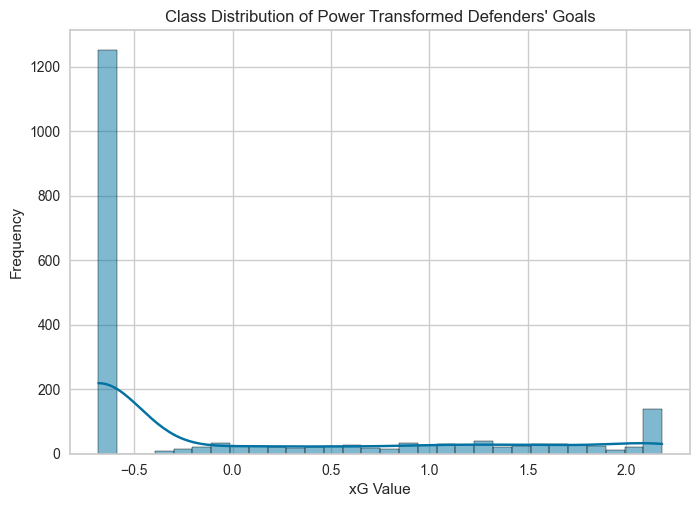

In [18]:
## TODO: XG PER 90????
def_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xg_data = def_data[def_xg_features]
def_xg_data_tar = def_data_tar[def_xg_features]

def_data.reset_index(drop=True, inplace=True)
def_xg_data.reset_index(drop=True, inplace=True)

def_xg_data.drop(columns=['position'], inplace=True)
def_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(def_xg_data['xG'].value_counts())

sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Defenders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xg.fit(def_xg_data[['xG']])
joblib.dump(pt_def_xg, './models/pt_def_xg.pkl')  # Save fitted transformer

def_xg_data['xG'] = pt_def_xg.transform(def_xg_data[['xG']])


sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Power Transformed Defenders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [19]:
def_xg_data

,xG,whh,whd,wha,was_home,team_h_difficulty,team_a_difficulty,percenatge_net_transfers,ict_index,influence,...,xG_5,xA_5,assists_x_5,assists_y_5,key_passes_5,npg_5,npxG_5,xGChain_5,xGBuildup_5,xP_5
0,1.243366,0.618,0.225,0.157,False,2,4,-0.383192,3.2,10.0,...,0.01,0.01,0.0,0.0,0.2,0.0,0.01,0.12,0.12,1.76
1,0.574619,0.526,0.249,0.225,True,2,2,0.639204,0.6,0.0,...,0.02,0.01,0.0,0.0,0.2,0.0,0.02,0.14,0.12,1.92
2,-0.680685,0.344,0.305,0.351,False,2,2,-0.402459,0.7,2.0,...,0.03,0.00,0.0,0.0,0.0,0.0,0.03,0.15,0.13,1.76
3,0.707546,0.572,0.227,0.201,False,2,4,-0.544130,0.0,0.0,...,0.03,0.00,0.0,0.0,0.0,0.0,0.03,0.13,0.11,1.46
4,-0.680685,0.579,0.239,0.182,False,2,3,-0.490372,2.0,15.6,...,0.04,0.00,0.0,0.0,0.0,0.0,0.04,0.10,0.08,1.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996,1.954263,0.431,0.306,0.263,False,2,2,-0.067259,3.1,22.0,...,0.13,0.06,0.0,0.0,0.2,0.2,0.13,0.09,0.03,2.38
1997,1.521875,0.572,0.255,0.174,True,2,2,0.772846,2.0,12.2,...,0.12,0.06,0.0,0.0,0.2,0.2,0.12,0.22,0.15,2.68
1998,-0.680685,0.745,0.167,0.087,False,2,5,-0.113902,4.0,27.0,...,0.11,0.06,0.0,0.0,0.2,0.0,0.11,0.27,0.22,3.22
1999,-0.680685,0.506,0.260,0.234,False,2,3,-0.286458,1.0,7.8,...,0.11,0.07,0.0,0.0,0.4,0.0,0.11,0.27,0.22,3.08


In [20]:
base_def_xg_model = setup(def_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xg_best = base_def_xg_model.compare_models(sort='MAE', n_select=1)
base_def_xg_best

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.062477 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4804
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 69
[LightGBM] [Info] Start training from score -0.009096


,Description,Value
0,Session id,4612
1,Target,xG
2,Target type,Regression
3,Original data shape,"(2001, 93)"
4,Transformed data shape,"(2001, 19)"
5,Transformed train set shape,"(1600, 19)"
6,Transformed test set shape,"(401, 19)"
7,Numeric features,91
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3093,0.2788,0.5258,0.7171,0.2334,1.0428,0.9320
rf,Random Forest Regressor,0.3111,0.2795,0.5269,0.7163,0.2375,1.0440,1.2040
gbr,Gradient Boosting Regressor,0.3407,0.2874,0.5350,0.7081,0.2517,1.1740,1.2040
xgboost,Extreme Gradient Boosting,0.3408,0.3058,0.5500,0.6895,0.2382,1.0556,0.9650
lightgbm,Light Gradient Boosting Machine,0.3496,0.3161,0.5600,0.6793,0.2444,1.1318,1.2350
dt,Decision Tree Regressor,0.3683,0.5185,0.7176,0.4737,0.2603,1.2670,0.7210
ada,AdaBoost Regressor,0.4057,0.3240,0.5673,0.6724,0.2631,1.1889,0.9490
huber,Huber Regressor,0.4177,0.4717,0.6865,0.5211,0.3143,0.8531,0.8380
knn,K Neighbors Regressor,0.4401,0.4523,0.6709,0.5417,0.3014,0.9780,0.8450
ridge,Ridge Regression,0.4895,0.4398,0.6628,0.5532,0.3407,0.8660,1.0330


ExtraTreesRegressor(n_jobs=-1, random_state=4612)

In [21]:
evaluate_model(base_def_xg_best)
# plot_model(base_fwd_y_best, plot='confusion_matrix')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

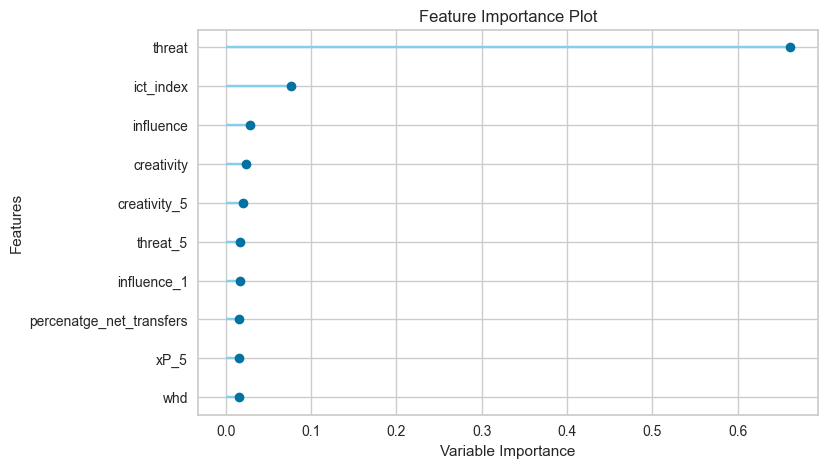

In [22]:
# plot_model(base_def_xg_best, plot='residuals')      # Residuals vs. predicted values
# plot_model(base_def_xg_best, plot='error')          # Prediction error plot
plot_model(base_def_xg_best, plot='feature')        # Feature importance

### Tune Model


In [23]:
def_xg_tuned = tune_model(base_def_xg_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.5330,0.4000,0.6324,0.6041,0.3388,0.9164
1,0.5425,0.4670,0.6834,0.5394,0.3718,0.6711
2,0.4961,0.4021,0.6341,0.5859,0.3360,0.7070
3,0.4970,0.4175,0.6462,0.5915,0.3354,0.8768
4,0.5326,0.4468,0.6684,0.5885,0.3561,1.6625
5,0.4682,0.3512,0.5926,0.5911,0.3246,1.0854
6,0.4937,0.3924,0.6264,0.5331,0.3396,0.9809
7,0.5550,0.4604,0.6785,0.5397,0.3520,0.9027
8,0.4900,0.3858,0.6211,0.6248,0.3431,0.9941


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [24]:
# Apply patch
# TransformerWrapper._reorder_cols = _reorder_cols
def_xg_final_model = finalize_model(base_def_xg_best)
save_model(def_xg_final_model, './models/def_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## Mid


In [25]:
mid_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

xG
0.000000    696
0.761169      9
0.046052      1
0.173475      1
0.036721      1
           ... 
0.130434      1
0.078979      1
0.535538      1
0.104962      1
0.121570      1
Name: count, Length: 1373, dtype: int64


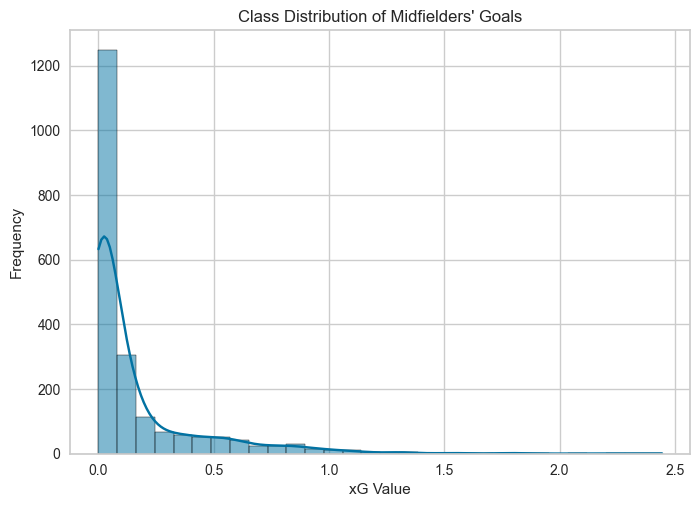

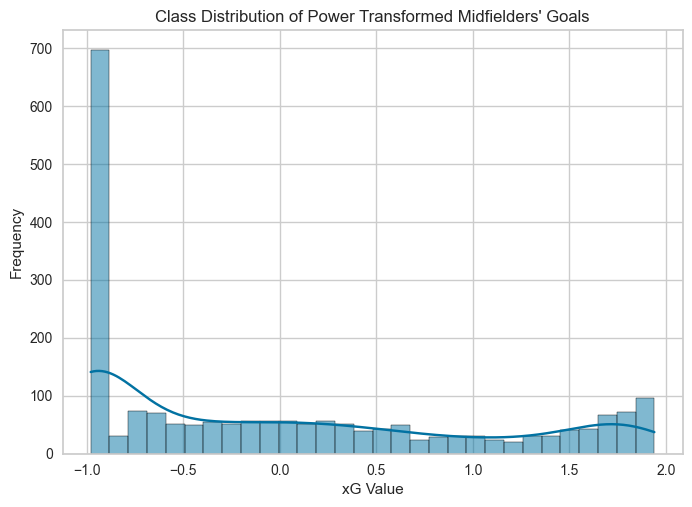

In [26]:

mid_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xg_data = mid_data[mid_xg_features]
mid_xg_data_tar = mid_data_tar[mid_xg_features]

mid_data.reset_index(drop=True, inplace=True)
mid_xg_data.reset_index(drop=True, inplace=True)

mid_xg_data.drop(columns=['position'], inplace=True)
mid_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(mid_xg_data['xG'].value_counts())

sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Midfielders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_mid_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_mid_xg.fit(mid_xg_data[['xG']])
joblib.dump(pt_mid_xg, './models/pt_mid_xg.pkl')  # Save fitted transformer

mid_xg_data['xG'] = pt_mid_xg.transform(mid_xg_data[['xG']])


sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Power Transformed Midfielders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [27]:
base_mid_xg_model = setup(mid_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xg_best = base_mid_xg_model.compare_models(sort='MAE')
base_mid_xg_best

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004867 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6001
[LightGBM] [Info] Number of data points in the train set: 1660, number of used features: 71
[LightGBM] [Info] Start training from score 0.008252


,Description,Value
0,Session id,6715
1,Target,xG
2,Target type,Regression
3,Original data shape,"(2076, 93)"
4,Transformed data shape,"(2076, 19)"
5,Transformed train set shape,"(1660, 19)"
6,Transformed test set shape,"(416, 19)"
7,Numeric features,91
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3586,0.2669,0.5149,0.7320,0.2611,2.1249,1.1920
rf,Random Forest Regressor,0.3589,0.2676,0.5153,0.7315,0.2636,2.1773,1.4820
gbr,Gradient Boosting Regressor,0.3671,0.2666,0.5150,0.7319,0.2617,2.3045,1.1040
lightgbm,Light Gradient Boosting Machine,0.3721,0.2787,0.5255,0.7202,0.2634,2.3766,1.2020
xgboost,Extreme Gradient Boosting,0.3895,0.3043,0.5498,0.6946,0.2669,2.5780,1.0710
knn,K Neighbors Regressor,0.4425,0.3578,0.5974,0.6418,0.2886,2.1374,0.9200
dt,Decision Tree Regressor,0.4543,0.4889,0.6981,0.5087,0.3061,2.7108,0.4690
ada,AdaBoost Regressor,0.4638,0.3170,0.5622,0.6819,0.2819,1.9007,1.0750
huber,Huber Regressor,0.4657,0.4089,0.6379,0.5912,0.2916,2.1373,0.5420
ridge,Ridge Regression,0.4845,0.3819,0.6171,0.6173,0.3049,1.8294,1.2150


ExtraTreesRegressor(n_jobs=-1, random_state=6715)

In [28]:
evaluate_model(base_mid_xg_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

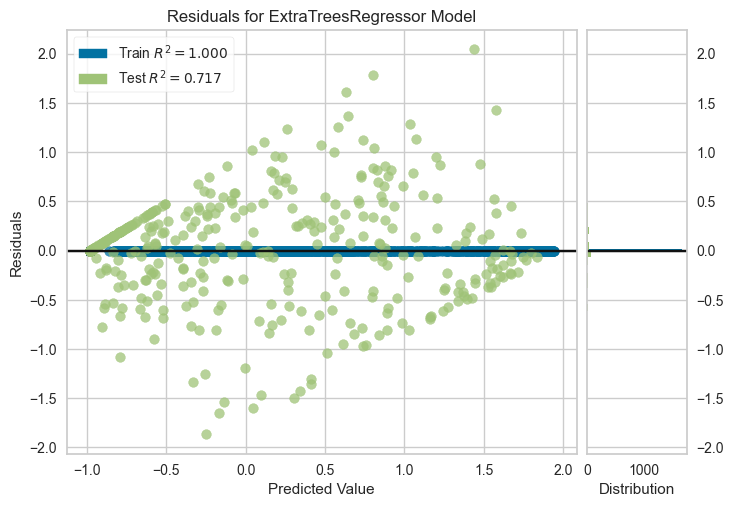

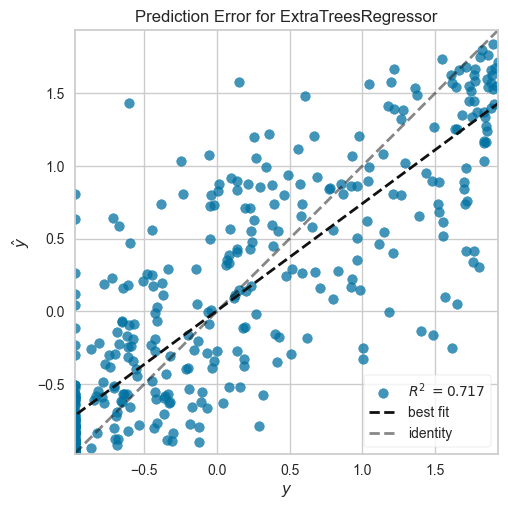

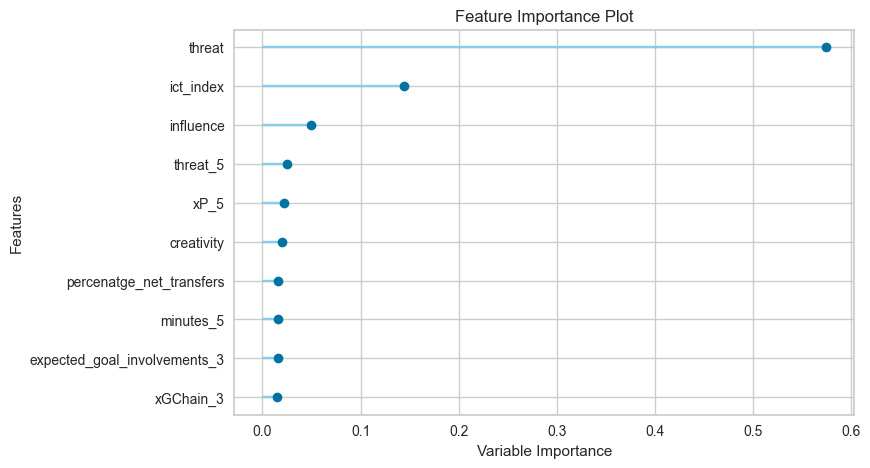

In [29]:
plot_model(base_mid_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xg_best, plot='error')          # Prediction error plot
plot_model(base_mid_xg_best, plot='feature')        # Feature importance

### Tune Model


In [30]:
mid_xg_tuned = tune_model(base_mid_xg_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3754,0.2698,0.5195,0.7524,0.2715,1.0576
1,0.2975,0.1805,0.4249,0.8083,0.2293,3.0586
2,0.3336,0.2314,0.4810,0.7626,0.2370,2.4265
3,0.3101,0.2029,0.4504,0.7988,0.2427,2.3592
4,0.3472,0.2707,0.5203,0.7149,0.2583,1.9286
5,0.3726,0.2787,0.5279,0.6860,0.2752,2.9570
6,0.3385,0.2480,0.4980,0.7481,0.2548,1.1058
7,0.3682,0.2767,0.5260,0.7434,0.2779,2.0426
8,0.3848,0.3088,0.5557,0.6834,0.2694,2.5850


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [31]:
mid_xg_final_model = finalize_model(base_mid_xg_best)
save_model(mid_xg_final_model, './models/mid_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## For


xG
0.000000    99
0.015542     1
0.261380     1
0.160622     1
0.247786     1
            ..
0.739986     1
0.525393     1
0.823317     1
0.134095     1
0.371195     1
Name: count, Length: 423, dtype: int64


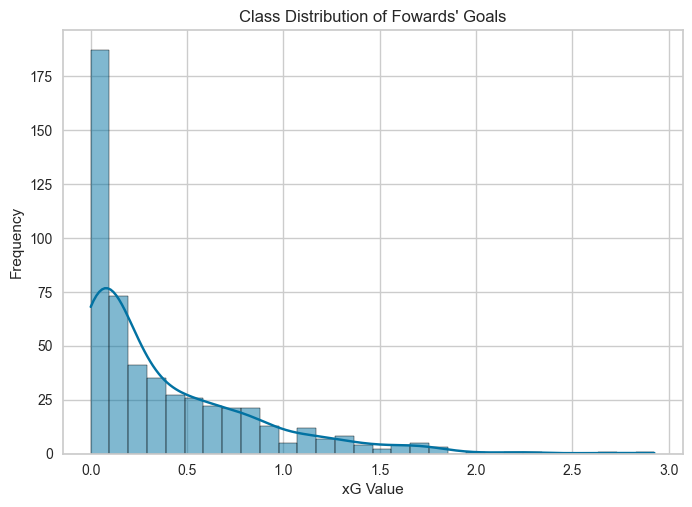

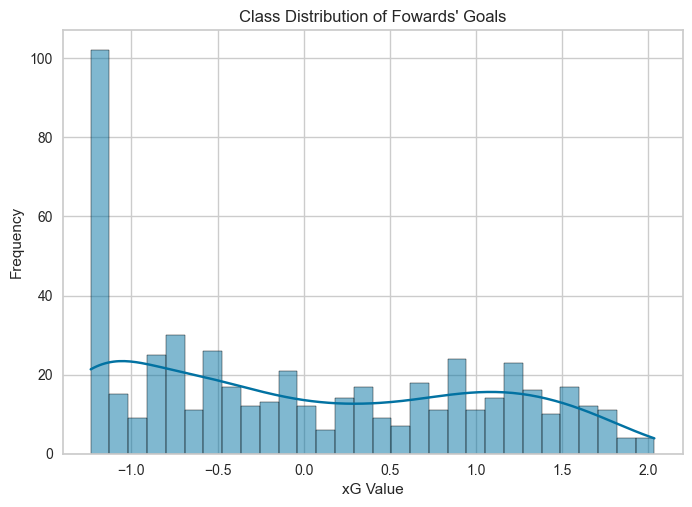

In [32]:
f_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',


            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]



fwd_xg_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xg_data = fwd_xg_data[f_xg_features]
fwd_xg_data_tar = fwd_data_tar[f_xg_features]

fwd_xg_data.reset_index(drop=True, inplace=True)
fwd_xg_data.reset_index(drop=True, inplace=True)

fwd_xg_data.drop(columns=['position'], inplace=True)
fwd_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(fwd_xg_data['xG'].value_counts())

sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Fowards\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_fwd_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_fwd_xg.fit(fwd_xg_data[['xG']])
joblib.dump(pt_fwd_xg, './models/pt_fwd_xg.pkl')  # Save fitted transformer

fwd_xg_data['xG'] = pt_fwd_xg.transform(fwd_xg_data[['xG']])


sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Fowards\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001684 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3169
[LightGBM] [Info] Number of data points in the train set: 416, number of used features: 64
[LightGBM] [Info] Start training from score 0.031100
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,Description,Value
0,Session id,3479
1,Target,xG
2,Target type,Regression
3,Original data shape,"(521, 93)"
4,Transformed data shape,"(521, 19)"
5,Transformed train set shape,"(416, 19)"
6,Transformed test set shape,"(105, 19)"
7,Numeric features,91
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.4536,0.3475,0.5863,0.6271,0.2824,1.1689,0.6350
rf,Random Forest Regressor,0.4666,0.3617,0.5973,0.6112,0.2855,1.2605,1.5120
gbr,Gradient Boosting Regressor,0.4727,0.3711,0.6062,0.6013,0.2790,1.2063,0.7800
xgboost,Extreme Gradient Boosting,0.4765,0.3887,0.6198,0.5838,0.2812,1.4582,1.2180
lightgbm,Light Gradient Boosting Machine,0.4766,0.3873,0.6186,0.5847,0.2826,1.6388,0.7440
huber,Huber Regressor,0.5035,0.4032,0.6323,0.5710,0.2784,1.6236,0.7360
lr,Linear Regression,0.5130,0.3923,0.6242,0.5804,0.2859,1.5260,0.1250
ridge,Ridge Regression,0.5152,0.3929,0.6247,0.5801,0.2843,1.5437,0.1380
br,Bayesian Ridge,0.5167,0.3922,0.6236,0.5812,0.2893,1.4002,0.3850
en,Elastic Net,0.5182,0.3884,0.6202,0.5849,0.2931,1.3052,0.4590


ExtraTreesRegressor(n_jobs=-1, random_state=3479)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


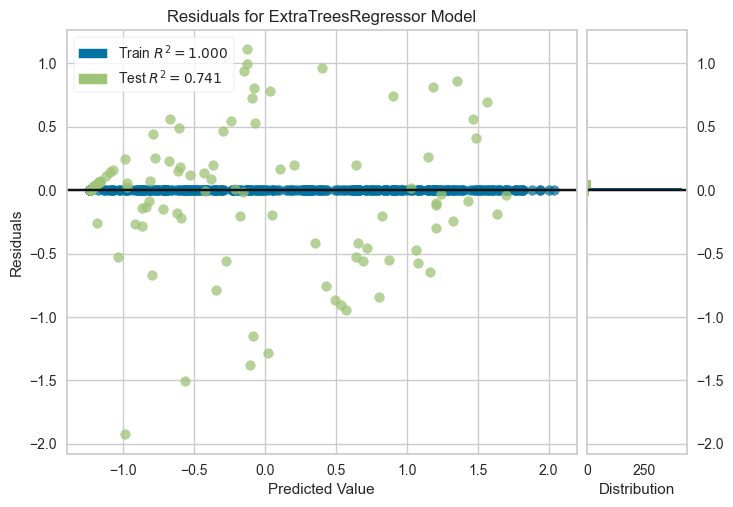

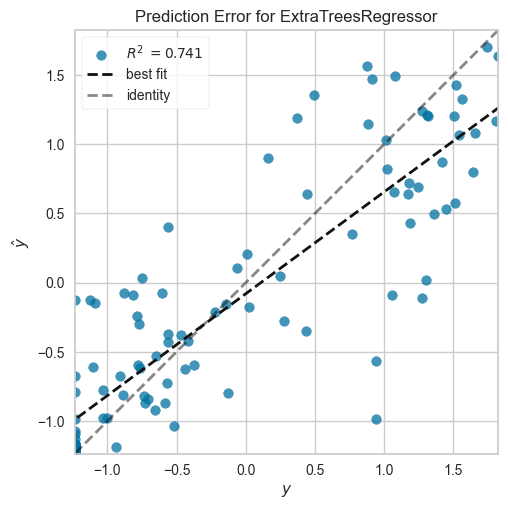

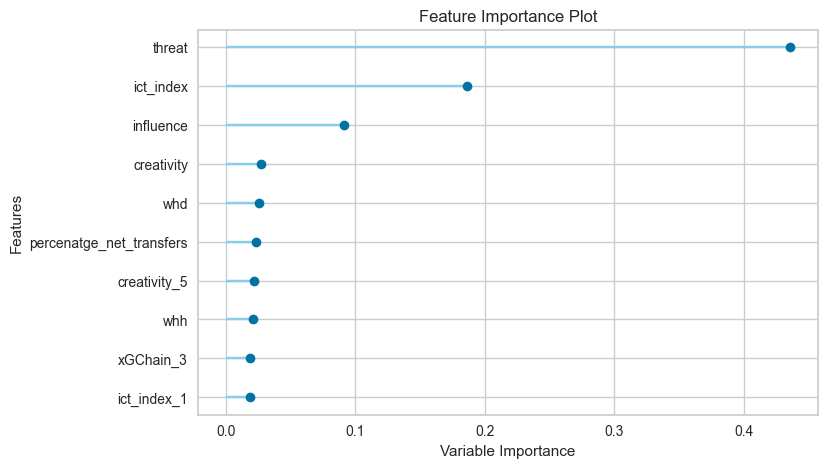

In [33]:
base_fwd_xg_model = setup(fwd_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xg_best = base_fwd_xg_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xg_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xg_best)

print('Plots...')
plot_model(base_fwd_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xg_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xg_best, plot='feature')        # Feature importance



### Tune Model


In [34]:
tuned_fwd_xg_model = tune_model(base_fwd_xg_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4105,0.2796,0.5288,0.6989,0.2692,1.4571
1,0.4790,0.3756,0.6129,0.6269,0.2989,0.6775
2,0.5220,0.4544,0.6741,0.5598,0.3148,0.7096
3,0.3553,0.2156,0.4643,0.7313,0.2444,1.0322
4,0.5219,0.3927,0.6267,0.5772,0.2692,1.1218
5,0.5100,0.4215,0.6493,0.4191,0.3022,1.9986
6,0.4501,0.3121,0.5586,0.6119,0.2279,2.8885
7,0.4049,0.2955,0.5436,0.7135,0.2440,0.6527
8,0.4429,0.2890,0.5375,0.7435,0.2746,0.9686


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [35]:
fwd_xg_final_model = finalize_model(tuned_fwd_xg_model)
save_model(fwd_xg_final_model, './models/fwd_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

# Assists


In [36]:
xa_features = [ 'position',  'xA', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence',
                 'creativity', 'threat','starts',

            'expected_assists_1', 'expected_goal_involvements_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'shots_1','xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'shots_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'shots_5',  'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

## Def


xA
0.000000    1360
0.053019       1
0.030822       1
0.060822       1
0.077340       1
            ... 
0.081697       1
0.021363       1
0.632110       1
0.221313       1
0.055309       1
Name: count, Length: 642, dtype: int64


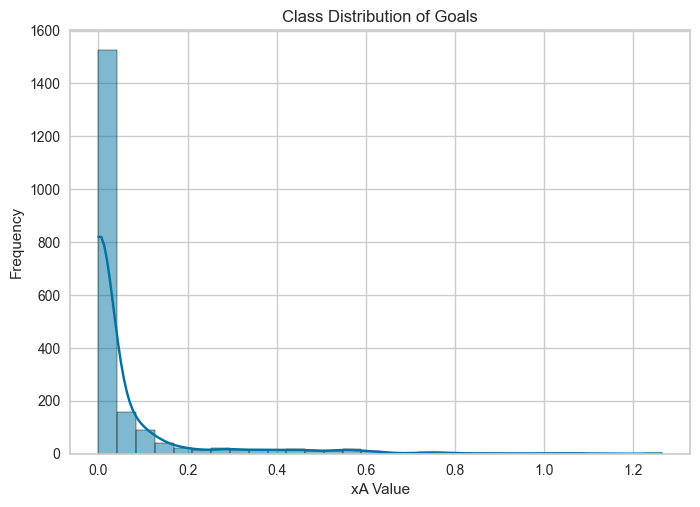

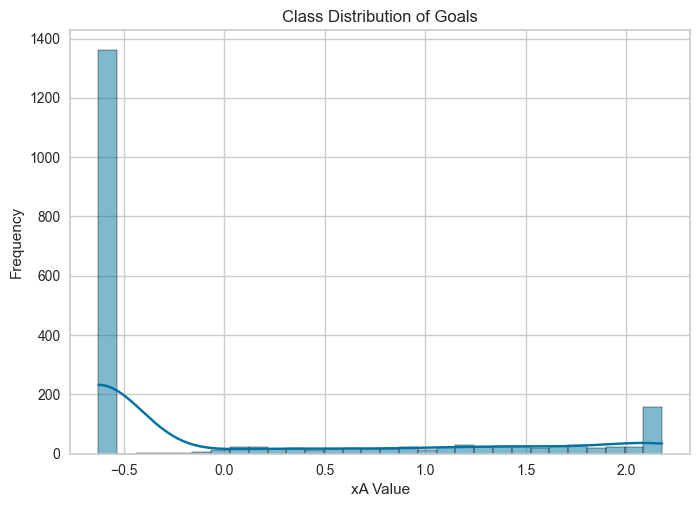

In [37]:
def_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xa_data = def_xa_data[xa_features]
def_xa_data_tar = def_xa_data_tar[xa_features]

def_xa_data.reset_index(drop=True, inplace=True)
def_xa_data.reset_index(drop=True, inplace=True)

def_xa_data.drop(columns=['position'], inplace=True)
def_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(def_xa_data['xA'].value_counts())

sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xa.fit(def_xa_data[['xA']])
joblib.dump(pt_def_xa, './models/pt_def_xa.pkl')  # Save fitted transformer

def_xa_data['xA'] = pt_def_xa.transform(def_xa_data[['xA']])


sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001057 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4932
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 64
[LightGBM] [Info] Start training from score 0.011868
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,Description,Value
0,Session id,6195
1,Target,xA
2,Target type,Regression
3,Original data shape,"(2001, 76)"
4,Transformed data shape,"(2001, 16)"
5,Transformed train set shape,"(1600, 16)"
6,Transformed test set shape,"(401, 16)"
7,Numeric features,74
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.1911,0.1751,0.4166,0.8248,0.1857,1.4474,1.1220
ada,AdaBoost Regressor,0.1978,0.1749,0.4162,0.8251,0.1830,1.3637,0.5920
et,Extra Trees Regressor,0.2004,0.1736,0.4155,0.8261,0.1872,1.4407,0.8550
gbr,Gradient Boosting Regressor,0.2088,0.1798,0.4225,0.8201,0.1886,1.4346,0.8250
lightgbm,Light Gradient Boosting Machine,0.2200,0.2001,0.4457,0.8001,0.2010,1.5022,1.0470
xgboost,Extreme Gradient Boosting,0.2235,0.2143,0.4609,0.7867,0.2067,1.2164,0.6440
knn,K Neighbors Regressor,0.2338,0.2301,0.4782,0.7679,0.2212,1.3119,0.6310
dt,Decision Tree Regressor,0.2640,0.3420,0.5821,0.6568,0.2543,0.8219,0.7530
huber,Huber Regressor,0.3455,0.4169,0.6372,0.5872,0.2880,0.6239,0.6750
ridge,Ridge Regression,0.4157,0.3940,0.6229,0.6081,0.3024,0.8252,0.6210


RandomForestRegressor(n_jobs=-1, random_state=6195)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


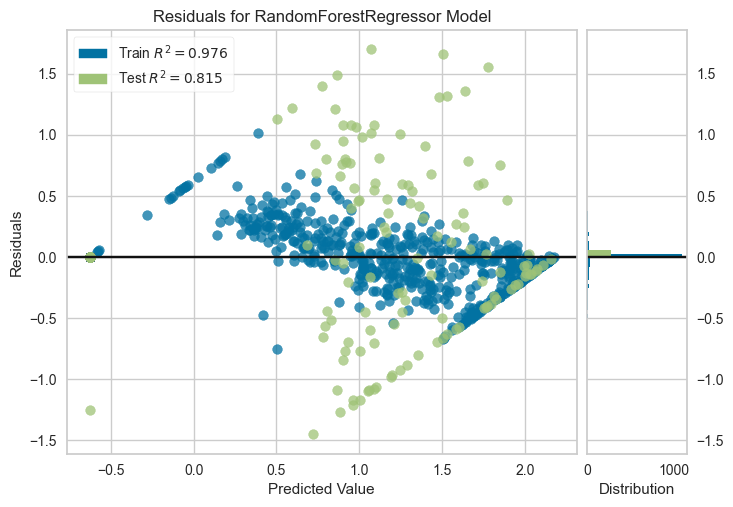

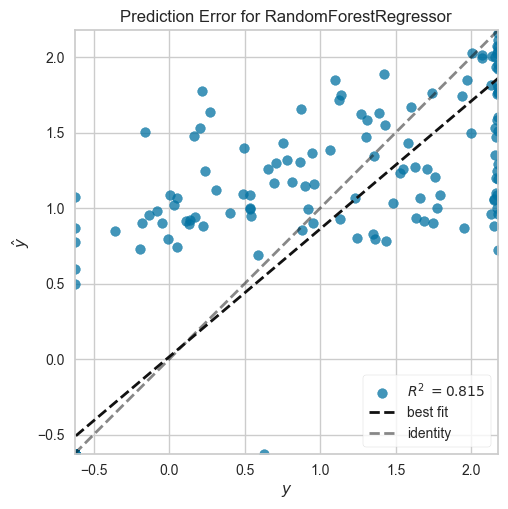

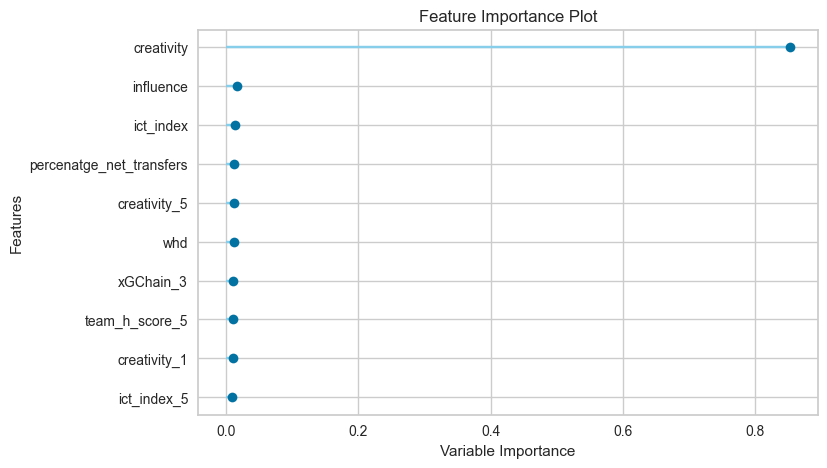

In [38]:
base_def_xa_model = setup(def_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xa_best = base_def_xa_model.compare_models(sort='MAE', n_select=1)
print(base_def_xa_best)

print('Évaluate the model...')
evaluate_model(base_def_xa_best)

print('Plots...')
plot_model(base_def_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xa_best, plot='error')          # Prediction error plot
plot_model(base_def_xa_best, plot='feature')        # Feature importance



### Tune Model


In [39]:
def_xa_tuned = tune_model(base_def_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2141,0.2001,0.4473,0.8092,0.1930,0.7358
1,0.2358,0.2112,0.4596,0.7980,0.1977,0.4783
2,0.2756,0.2777,0.5270,0.7080,0.2408,8.3411
3,0.1982,0.1822,0.4269,0.8311,0.1652,0.2738
4,0.2197,0.2051,0.4529,0.7690,0.2020,0.7202
5,0.1682,0.1486,0.3855,0.8188,0.1761,3.4267
6,0.2185,0.1870,0.4324,0.8325,0.2009,0.6408
7,0.2989,0.2917,0.5401,0.7172,0.2457,1.9433
8,0.1773,0.1559,0.3948,0.8389,0.1678,0.3549


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [40]:
def_xa_final_model = finalize_model(base_def_xa_best)
save_model(def_xa_final_model, './models/def_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


## Mid


xA
0.000000    833
0.027188      1
0.045372      1
0.046504      1
0.884835      1
           ... 
0.040680      1
0.063970      1
0.092061      1
0.189078      1
0.048324      1
Name: count, Length: 1244, dtype: int64


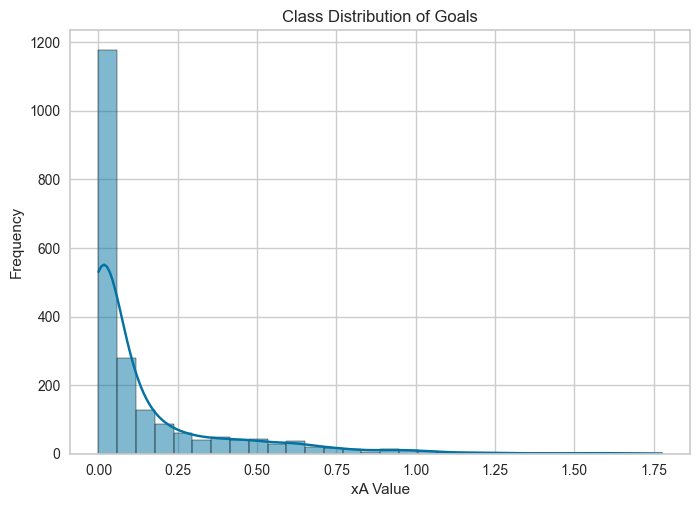

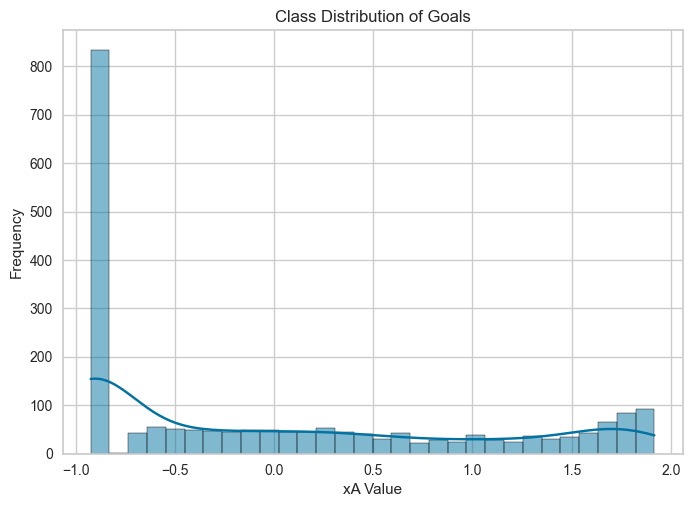

In [41]:

mid_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xa_data = mid_xa_data[xa_features]
mid_xa_data_tar = mid_xa_data_tar[xa_features]

mid_xa_data.reset_index(drop=True, inplace=True)
mid_xa_data.reset_index(drop=True, inplace=True)

mid_xa_data.drop(columns=['position'], inplace=True)
mid_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(mid_xa_data['xA'].value_counts())

sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_mid_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_mid_xa.fit(mid_xa_data[['xA']])
joblib.dump(pt_mid_xa, './models/pt_mid_xa.pkl')  # Save fitted transformer

mid_xa_data['xA'] = pt_mid_xa.transform(mid_xa_data[['xA']])


sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6227
[LightGBM] [Info] Number of data points in the train set: 1660, number of used features: 66
[LightGBM] [Info] Start training from score 0.011708


,Description,Value
0,Session id,4961
1,Target,xA
2,Target type,Regression
3,Original data shape,"(2076, 76)"
4,Transformed data shape,"(2076, 16)"
5,Transformed train set shape,"(1660, 16)"
6,Transformed test set shape,"(416, 16)"
7,Numeric features,74
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3581,0.3011,0.5482,0.6975,0.2721,3.1045,1.3560
rf,Random Forest Regressor,0.3588,0.3066,0.5531,0.6919,0.2725,2.7071,1.5710
gbr,Gradient Boosting Regressor,0.3702,0.3052,0.5518,0.6934,0.2743,1.9750,1.4620
ada,AdaBoost Regressor,0.3777,0.3168,0.5625,0.6814,0.2501,2.6699,0.6820
lightgbm,Light Gradient Boosting Machine,0.3829,0.3295,0.5733,0.6685,0.2706,3.7574,2.5810
xgboost,Extreme Gradient Boosting,0.4044,0.3602,0.5996,0.6376,0.2791,2.9695,0.6570
knn,K Neighbors Regressor,0.4115,0.3802,0.6163,0.6175,0.2802,2.2988,0.9350
huber,Huber Regressor,0.4162,0.4001,0.6317,0.5988,0.2929,2.3829,0.9530
br,Bayesian Ridge,0.4530,0.3796,0.6153,0.6193,0.3072,1.9638,1.3250
lr,Linear Regression,0.4531,0.3808,0.6164,0.6180,0.3073,1.9141,1.2470


ExtraTreesRegressor(n_jobs=-1, random_state=4961)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


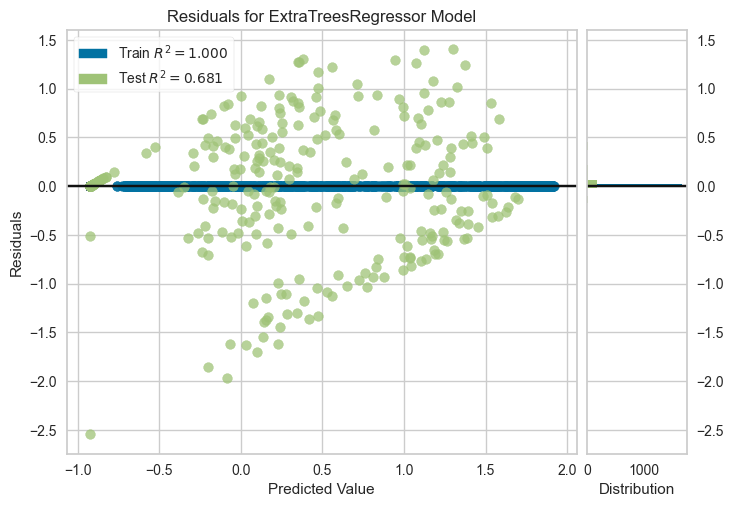

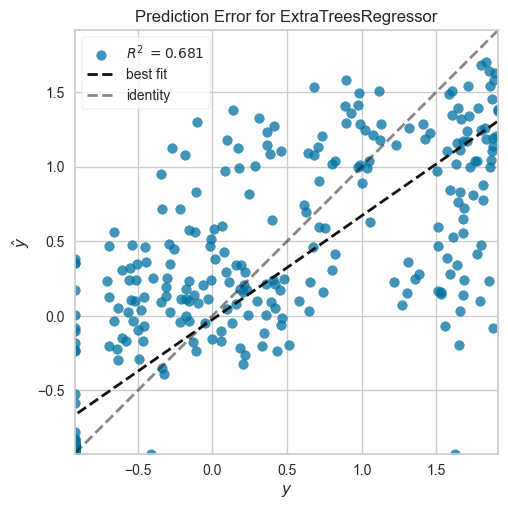

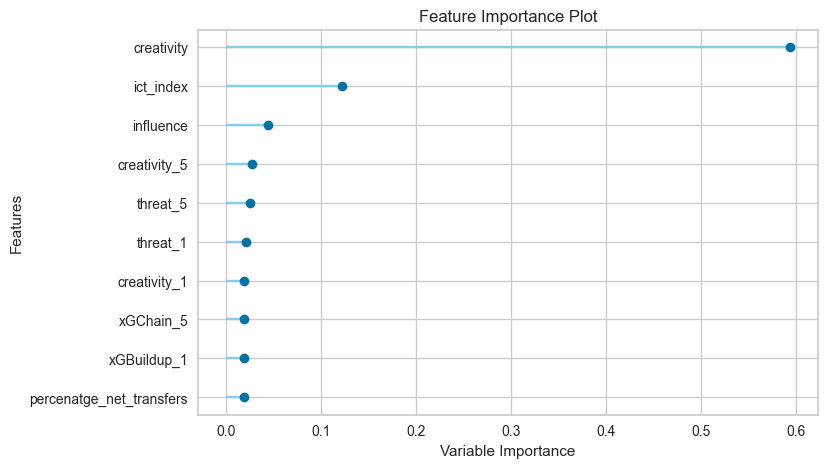

In [42]:
base_mid_xa_model = setup(mid_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xa_best = base_mid_xa_model.compare_models(sort='MAE', n_select=1)
print(base_mid_xa_best)

print('Évaluate the model...')
evaluate_model(base_mid_xa_best)

print('Plots...')
plot_model(base_mid_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xa_best, plot='error')          # Prediction error plot
plot_model(base_mid_xa_best, plot='feature')        # Feature importance



### Tune model


In [43]:
mid_xa_tuned = tune_model(base_mid_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4058,0.3338,0.5777,0.6522,0.2936,16.4385
1,0.3796,0.3539,0.5949,0.6637,0.2899,0.7544
2,0.4339,0.3396,0.5828,0.6744,0.2905,1.5674
3,0.4094,0.3360,0.5796,0.6540,0.2866,1.4827
4,0.4078,0.3939,0.6276,0.5988,0.2965,1.9801
5,0.4056,0.3599,0.6000,0.6266,0.2976,1.9281
6,0.4099,0.3621,0.6018,0.6349,0.2751,0.9725
7,0.3926,0.3541,0.5951,0.6435,0.2878,1.1131
8,0.4176,0.3749,0.6123,0.6457,0.2872,1.4329


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [44]:
mid_xa_final_model = finalize_model(base_mid_xa_best)
save_model(mid_xa_final_model, './models/mid_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


## For


xA
0.000000    243
0.283901      1
0.444472      1
0.130812      1
0.079388      1
           ... 
0.073714      1
0.469325      1
0.924203      1
0.172124      1
0.294103      1
Name: count, Length: 279, dtype: int64


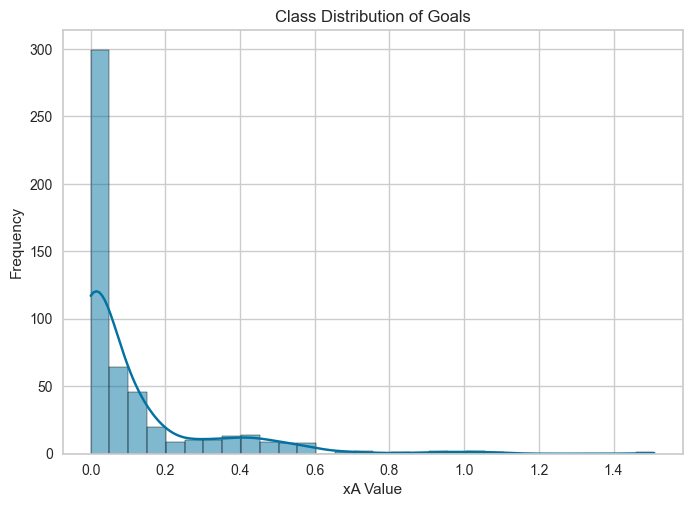

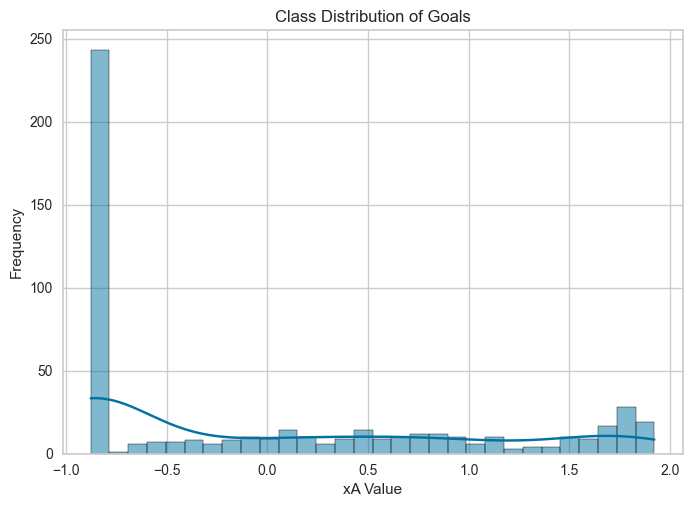

In [45]:

fwd_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xa_data = fwd_xa_data[xa_features]
fwd_xa_data_tar = fwd_xa_data_tar[xa_features]

fwd_xa_data.reset_index(drop=True, inplace=True)
fwd_xa_data.reset_index(drop=True, inplace=True)

fwd_xa_data.drop(columns=['position'], inplace=True)
fwd_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)



print(fwd_xa_data['xA'].value_counts())

sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_fwd_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_fwd_xa.fit(fwd_xa_data[['xA']])
joblib.dump(pt_fwd_xa, './models/pt_fwd_xa.pkl')  # Save fitted transformer

fwd_xa_data['xA'] = pt_fwd_xa.transform(fwd_xa_data[['xA']])


sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.077890 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3330
[LightGBM] [Info] Number of data points in the train set: 416, number of used features: 66
[LightGBM] [Info] Start training from score -0.029712
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,Description,Value
0,Session id,3536
1,Target,xA
2,Target type,Regression
3,Original data shape,"(521, 76)"
4,Transformed data shape,"(521, 16)"
5,Transformed train set shape,"(416, 16)"
6,Transformed test set shape,"(105, 16)"
7,Numeric features,74
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3007,0.2490,0.4949,0.7380,0.2278,1.8613,1.3440
et,Extra Trees Regressor,0.3032,0.2454,0.4908,0.7429,0.2335,1.6298,0.6650
xgboost,Extreme Gradient Boosting,0.3232,0.2693,0.5121,0.7172,0.2415,2.1677,0.4660
gbr,Gradient Boosting Regressor,0.3422,0.2730,0.5180,0.7121,0.2462,1.6458,0.5950
lightgbm,Light Gradient Boosting Machine,0.3531,0.2825,0.5248,0.7042,0.2502,2.2082,0.4110
ada,AdaBoost Regressor,0.3641,0.2776,0.5207,0.7096,0.2437,2.0117,0.3200
dt,Decision Tree Regressor,0.3980,0.4608,0.6592,0.5224,0.2739,1.7464,0.2220
huber,Huber Regressor,0.4058,0.4021,0.6264,0.5783,0.2909,0.8244,0.6620
knn,K Neighbors Regressor,0.4231,0.3914,0.6219,0.5826,0.2942,1.4942,1.1780
ridge,Ridge Regression,0.4427,0.3805,0.6126,0.5977,0.3073,0.7985,0.3880


RandomForestRegressor(n_jobs=-1, random_state=3536)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


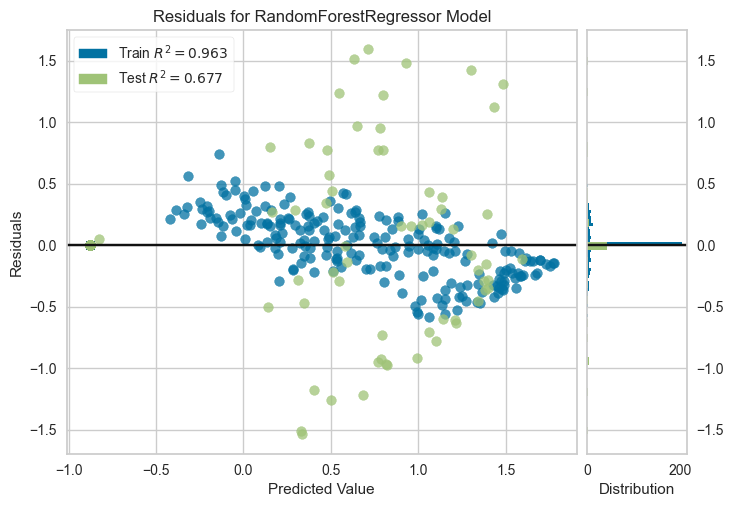

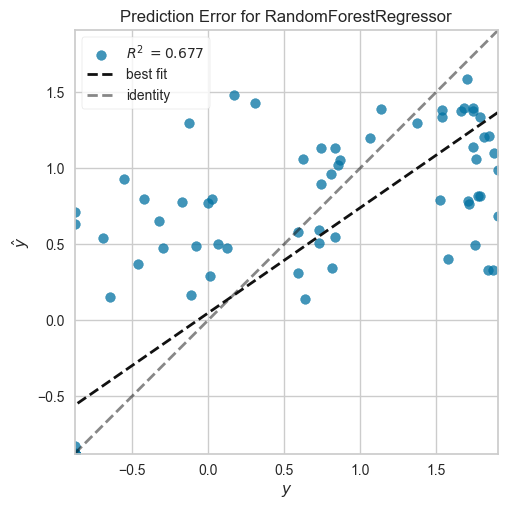

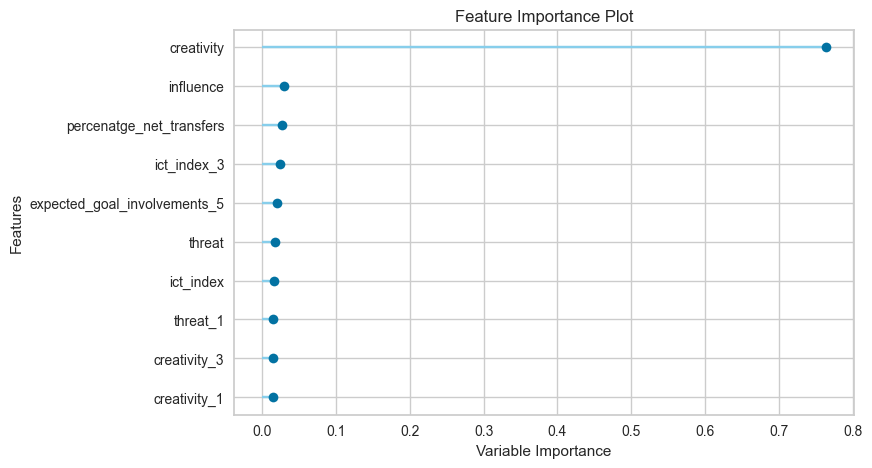

In [46]:
base_fwd_xa_model = setup(fwd_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xa_best = base_fwd_xa_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xa_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xa_best)

print('Plots...')
plot_model(base_fwd_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xa_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xa_best, plot='feature')        # Feature importance

### Tune model


In [47]:
fwd_xa_tuned = tune_model(base_fwd_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3310,0.2814,0.5304,0.7271,0.2228,1.2043
1,0.2239,0.1532,0.3913,0.8288,0.1820,0.3640
2,0.3133,0.2613,0.5111,0.7145,0.2191,0.8858
3,0.3307,0.3539,0.5949,0.6632,0.3030,0.6680
4,0.2756,0.1986,0.4457,0.7256,0.2060,11.4973
5,0.2673,0.1964,0.4432,0.7891,0.2014,0.5139
6,0.3973,0.3540,0.5950,0.6456,0.2776,0.7406
7,0.2937,0.2504,0.5004,0.7702,0.2280,0.6642
8,0.2110,0.1439,0.3793,0.8132,0.1644,0.5132


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [48]:
fwd_xa_final_model = finalize_model(base_fwd_xa_best)
save_model(fwd_xa_final_model, './models/fwd_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


# Saves


## GK


saves
2     113
3     106
1      82
4      81
5      47
0      30
6      25
7      17
8      12
9       6
10      4
12      1
Name: count, dtype: int64


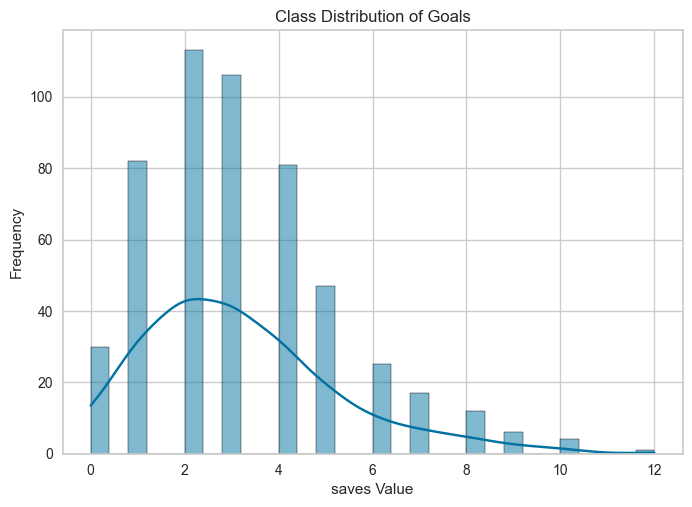

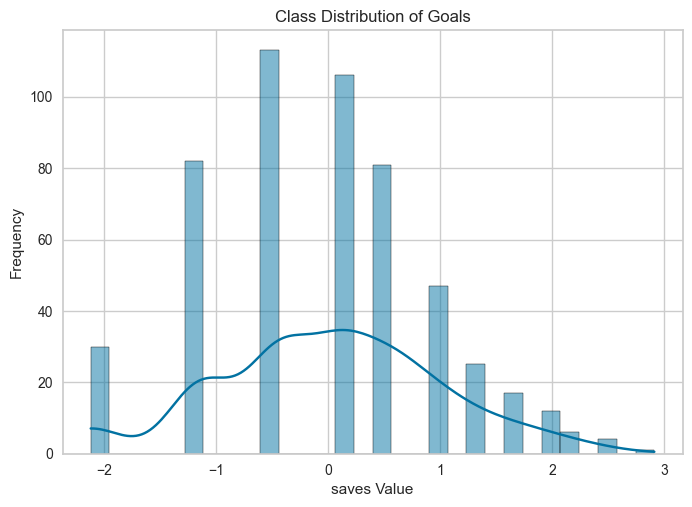

In [49]:
saves_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'saves',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



g_saves_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_saves_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_saves_data = g_saves_data[saves_features]
g_saves_data_tar = g_saves_data_tar[saves_features]

g_saves_data.reset_index(drop=True, inplace=True)
g_saves_data.reset_index(drop=True, inplace=True)

g_saves_data.drop(columns=['position'], inplace=True)
g_saves_data_tar.drop(columns=['position', 'saves'], inplace=True)

print(g_saves_data['saves'].value_counts())

sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

pt_gk_saves = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_gk_saves.fit(g_saves_data[['saves']])
joblib.dump(pt_gk_saves, './models/pt_gk_saves.pkl')  # Save fitted transformer

g_saves_data['saves'] = pt_gk_saves.transform(g_saves_data[['saves']])


sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004327 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1774
[LightGBM] [Info] Number of data points in the train set: 419, number of used features: 47
[LightGBM] [Info] Start training from score 0.033105
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,Description,Value
0,Session id,248
1,Target,saves
2,Target type,Regression
3,Original data shape,"(524, 75)"
4,Transformed data shape,"(524, 15)"
5,Transformed train set shape,"(419, 15)"
6,Transformed test set shape,"(105, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.2658,0.1200,0.3416,0.8674,0.1763,0.6907,0.6970
rf,Random Forest Regressor,0.2667,0.1225,0.3446,0.8643,0.1771,0.7397,0.5170
gbr,Gradient Boosting Regressor,0.2678,0.1185,0.3403,0.8693,0.1796,0.7157,0.5160
lightgbm,Light Gradient Boosting Machine,0.2789,0.1295,0.3543,0.8560,0.1860,0.7838,0.5700
xgboost,Extreme Gradient Boosting,0.2802,0.1366,0.3616,0.8484,0.1869,0.8104,0.7170
ada,AdaBoost Regressor,0.2857,0.1315,0.3583,0.8563,0.1870,0.6499,0.5020
dt,Decision Tree Regressor,0.2977,0.2133,0.4569,0.7668,0.2331,0.9752,0.2810
ridge,Ridge Regression,0.3062,0.1588,0.3938,0.8393,0.1932,0.7651,0.9290
lar,Least Angle Regression,0.3065,0.1594,0.3944,0.8390,0.1932,0.7700,0.6460
lr,Linear Regression,0.3071,0.1595,0.3945,0.8388,0.1938,0.7682,0.8030


ExtraTreesRegressor(n_jobs=-1, random_state=248)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


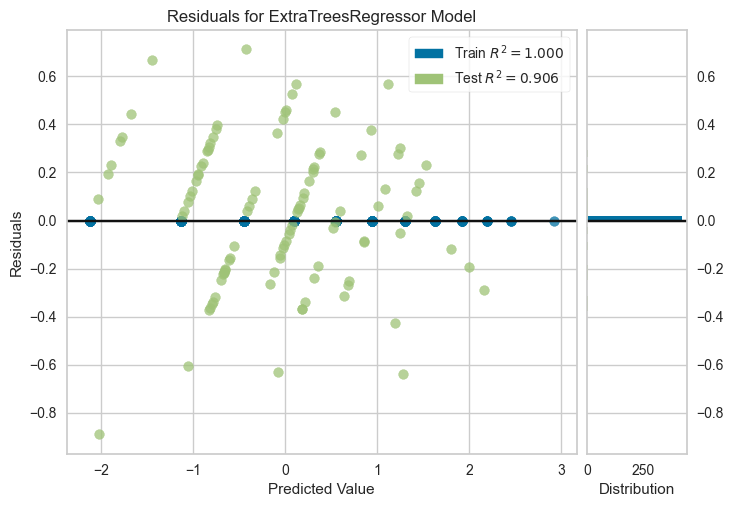

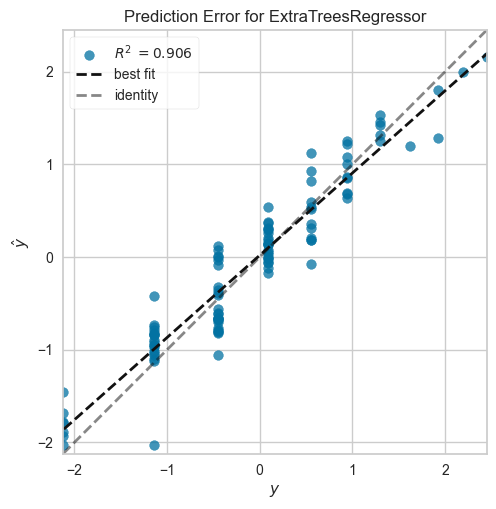

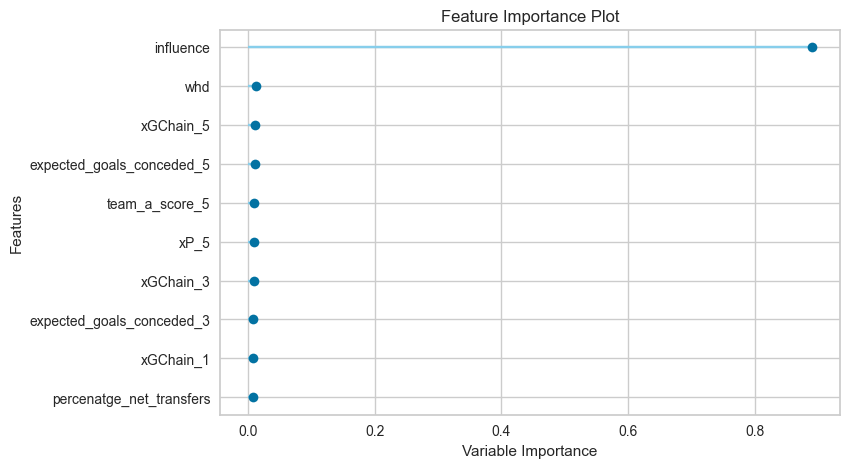

In [50]:
base_g_saves_model = setup(g_saves_data, target = 'saves',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_saves_best = base_g_saves_model.compare_models(sort='MAE', n_select=1)
print(base_g_saves_best)

print('Évaluate the model...')
evaluate_model(base_g_saves_best)

print('Plots...')
plot_model(base_g_saves_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_saves_best, plot='error')          # Prediction error plot
plot_model(base_g_saves_best, plot='feature')        # Feature importance

### Tune Model


In [51]:
g_saves_tuned = tune_model(base_g_saves_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3117,0.1522,0.3901,0.8307,0.1976,0.9045
1,0.3034,0.1987,0.4458,0.6457,0.1951,0.7645
2,0.2343,0.0988,0.3143,0.8911,0.1725,0.5744
3,0.2890,0.1550,0.3937,0.8762,0.1899,0.7631
4,0.2347,0.0889,0.2982,0.9129,0.1611,0.4928
5,0.2313,0.0918,0.3030,0.9157,0.1647,0.7117
6,0.2816,0.1290,0.3592,0.9020,0.1831,0.6457
7,0.2045,0.0684,0.2615,0.9266,0.1378,0.5470
8,0.2389,0.1228,0.3504,0.8846,0.1843,0.6441


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [52]:
g_saves_final_model = finalize_model(base_g_saves_best)
save_model(g_saves_final_model, './models/g_saves_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
 

# Goals Conceded


In [53]:
xgc_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',
            'expected_goals_conceded',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3',  'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

## GK


expected_goals_conceded
1.69    6
1.87    6
0.56    6
1.71    6
0.59    6
       ..
3.59    1
3.19    1
0.37    1
2.62    1
2.99    1
Name: count, Length: 249, dtype: int64


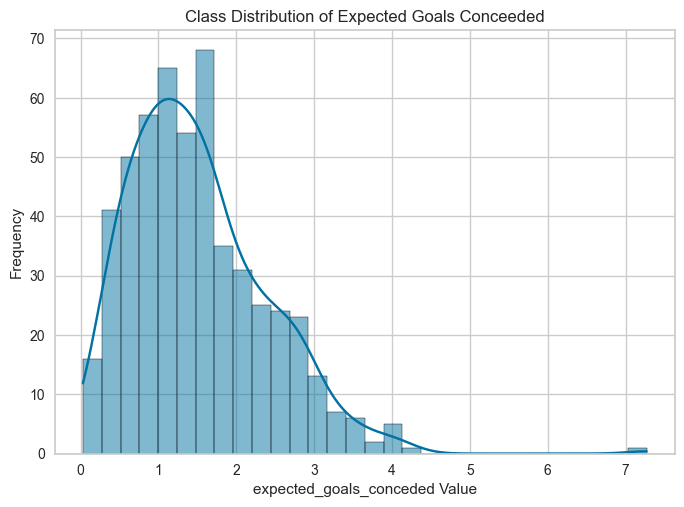

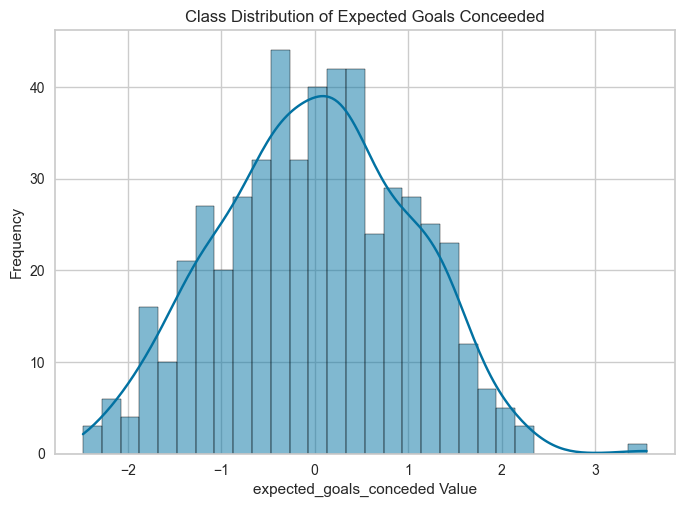

In [54]:
g_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_xgc_data = g_xgc_data[xgc_features]
g_xgc_data_tar = g_xgc_data_tar[xgc_features]

g_xgc_data.reset_index(drop=True, inplace=True)
g_xgc_data.reset_index(drop=True, inplace=True)

g_xgc_data.drop(columns=['position'], inplace=True)
g_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(g_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt_gk_xgc = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_gk_xgc.fit(g_xgc_data[['expected_goals_conceded']])
joblib.dump(pt_gk_xgc, './models/pt_gk_xgc.pkl')  # Save fitted transformer

g_xgc_data['expected_goals_conceded'] = pt_gk_xgc.transform(g_xgc_data[['expected_goals_conceded']])


sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001973 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1681
[LightGBM] [Info] Number of data points in the train set: 419, number of used features: 47
[LightGBM] [Info] Start training from score -0.030151
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,Description,Value
0,Session id,1351
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(524, 70)"
4,Transformed data shape,"(524, 14)"
5,Transformed train set shape,"(419, 14)"
6,Transformed test set shape,"(105, 14)"
7,Numeric features,68
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.7231,0.7685,0.8722,0.2371,0.4044,2.9988,0.4050
ridge,Ridge Regression,0.7231,0.7675,0.8717,0.2382,0.4049,2.9191,0.5420
et,Extra Trees Regressor,0.7254,0.7899,0.8792,0.2328,0.4161,2.2485,2.5200
br,Bayesian Ridge,0.7279,0.7725,0.8745,0.2353,0.4112,2.3513,0.6880
rf,Random Forest Regressor,0.7388,0.8208,0.8973,0.1957,0.4216,2.6456,0.9270
ada,AdaBoost Regressor,0.7402,0.7975,0.8851,0.2213,0.4391,2.7229,0.7380
en,Elastic Net,0.7519,0.8080,0.8947,0.2001,0.4362,2.1999,0.4780
lightgbm,Light Gradient Boosting Machine,0.7527,0.8576,0.9177,0.1581,0.4030,3.5250,0.6490
lasso,Lasso Regression,0.7529,0.8113,0.8965,0.1979,0.4434,2.0959,0.4510
llar,Lasso Least Angle Regression,0.7529,0.8113,0.8965,0.1979,0.4434,2.0959,0.5190


LinearRegression(n_jobs=-1)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


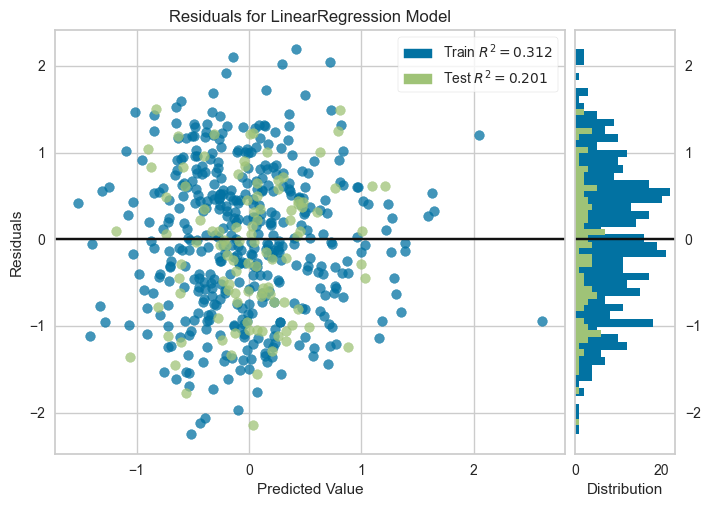

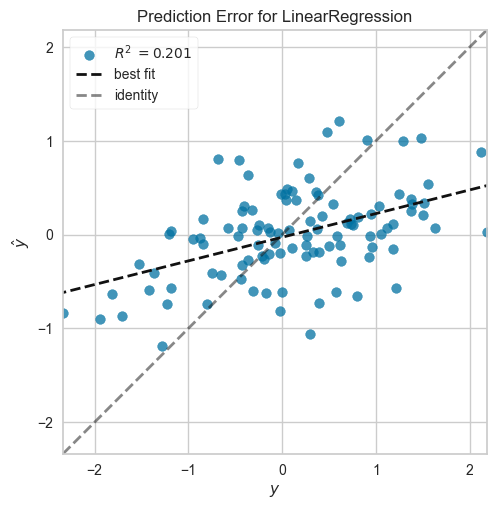

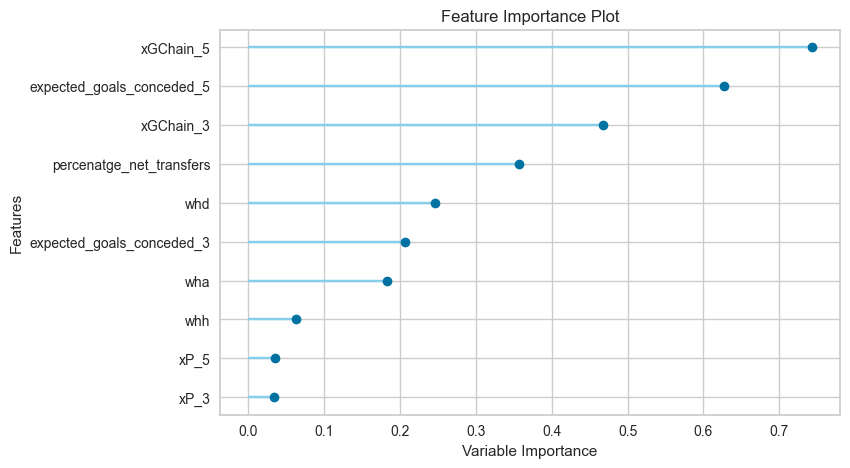

In [55]:
base_g_xgc_model = setup(g_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_xgc_best = base_g_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_g_xgc_best)

print('Évaluate the model...')
evaluate_model(base_g_xgc_best)

print('Plots...')
plot_model(base_g_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_xgc_best, plot='error')          # Prediction error plot
plot_model(base_g_xgc_best, plot='feature')        # Feature importance

### Tuned Model


In [56]:
g_xgc_tuned = tune_model(base_g_xgc_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.7870,0.8960,0.9466,0.1562,0.4572,1.5257
1,0.7108,0.8048,0.8971,0.2229,0.3960,6.4448
2,0.6971,0.6664,0.8163,0.2950,0.3821,1.6507
3,0.9123,1.0259,1.0129,0.3865,0.5037,1.8137
4,0.7539,0.8430,0.9181,0.1892,0.4527,5.3394
5,0.6686,0.7042,0.8391,0.2063,0.3716,2.0670
6,0.7466,0.9110,0.9545,-0.0295,0.3776,6.8872
7,0.7129,0.7567,0.8699,0.2488,0.4272,1.8767
8,0.6130,0.5366,0.7325,0.3008,0.3235,1.3999


Fitting 10 folds for each of 2 candidates, totalling 20 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [57]:
g_xgc_final_model = finalize_model(g_xgc_tuned)
save_model(g_xgc_final_model, './models/g_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## Def


expected_goals_conceded
0.83    25
1.87    21
0.00    19
1.88    18
1.13    18
        ..
3.26     1
2.68     1
3.63     1
2.47     1
3.52     1
Name: count, Length: 314, dtype: int64


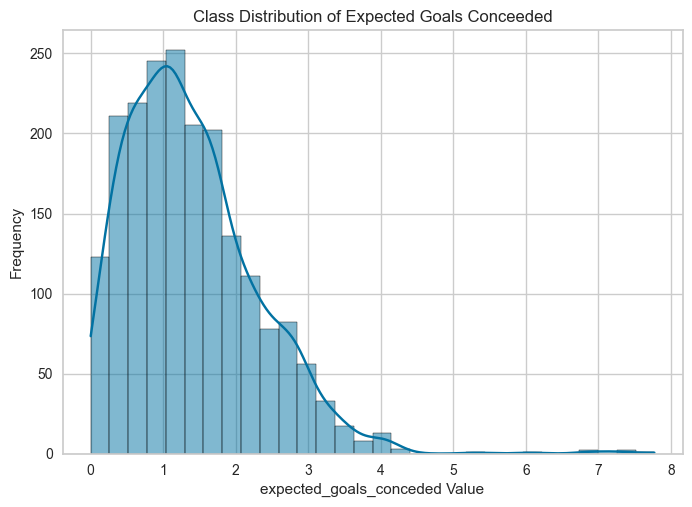

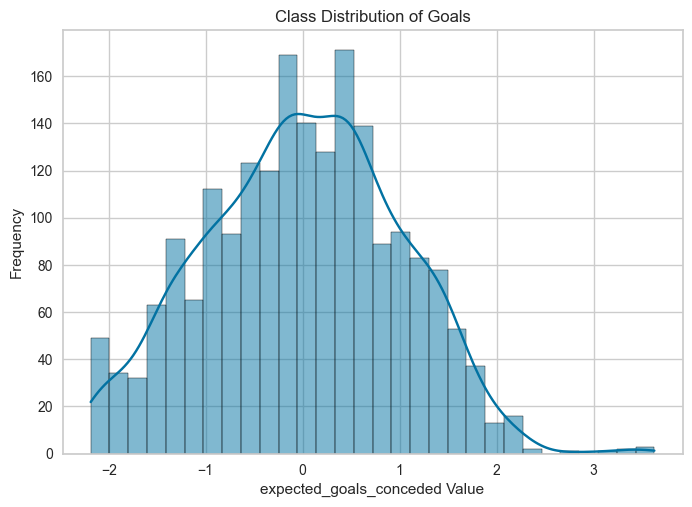

In [58]:
def_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xgc_data = def_xgc_data[xgc_features]
def_xgc_data_tar = def_xgc_data_tar[xgc_features]

def_xgc_data.reset_index(drop=True, inplace=True)
def_xgc_data.reset_index(drop=True, inplace=True)

def_xgc_data.drop(columns=['position'], inplace=True)
def_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(def_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xgc = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xgc.fit(def_xgc_data[['expected_goals_conceded']])
joblib.dump(pt_def_xgc, './models/pt_def_xgc.pkl')  # Save fitted transformer

def_xgc_data['expected_goals_conceded'] = pt_def_xgc.transform(def_xgc_data[['expected_goals_conceded']])


sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Goals')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001440 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5450
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 58
[LightGBM] [Info] Start training from score -0.010354


,Description,Value
0,Session id,6644
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(2001, 70)"
4,Transformed data shape,"(2001, 14)"
5,Transformed train set shape,"(1600, 14)"
6,Transformed test set shape,"(401, 14)"
7,Numeric features,68
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.6722,0.7379,0.8573,0.2609,0.3868,2.5203,0.7260
rf,Random Forest Regressor,0.6754,0.7370,0.8563,0.2642,0.4110,2.0968,2.5000
et,Extra Trees Regressor,0.6770,0.7340,0.8549,0.2667,0.4146,1.8896,1.8930
xgboost,Extreme Gradient Boosting,0.6889,0.7621,0.8713,0.2362,0.3866,3.0064,1.1860
gbr,Gradient Boosting Regressor,0.6944,0.7737,0.8774,0.2277,0.4159,2.0837,1.4770
ada,AdaBoost Regressor,0.7607,0.8697,0.9313,0.1317,0.4933,1.6177,1.2080
lr,Linear Regression,0.7687,0.9041,0.9495,0.0970,0.4654,1.8732,0.9830
ridge,Ridge Regression,0.7688,0.9041,0.9495,0.0971,0.4656,1.8788,0.8650
br,Bayesian Ridge,0.7701,0.9038,0.9494,0.0973,0.4736,1.8256,0.6280
en,Elastic Net,0.7971,0.9560,0.9764,0.0457,0.5253,1.4453,1.0180


LGBMRegressor(n_jobs=-1, random_state=6644)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


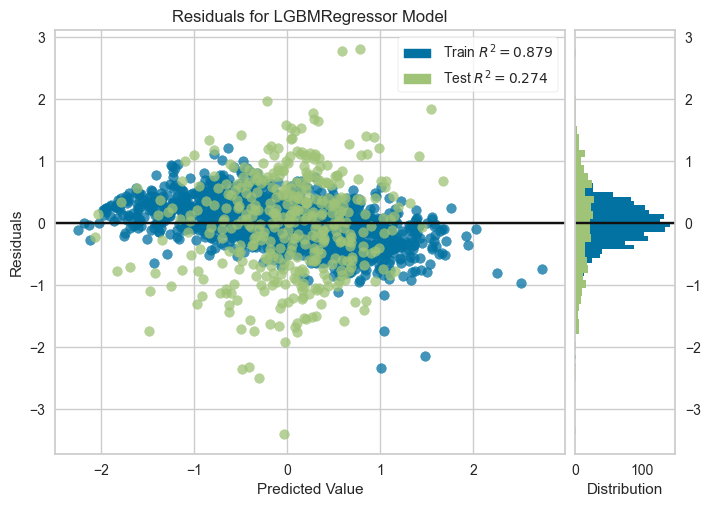

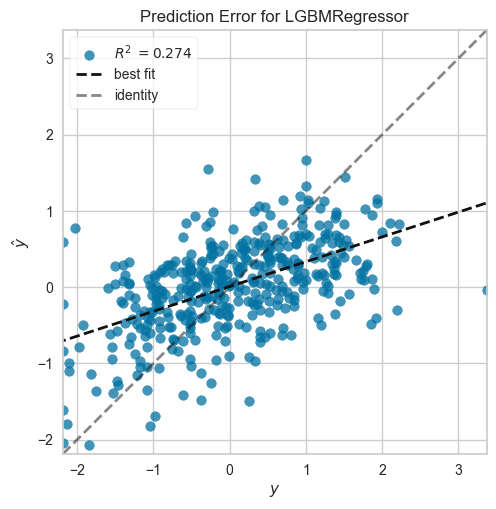

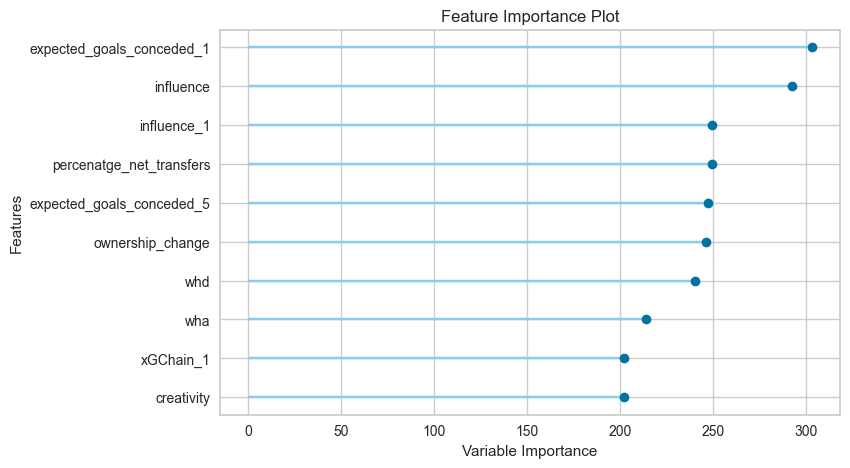

In [59]:
base_def_xgc_model = setup(def_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xgc_best = base_def_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_def_xgc_best)

print('Évaluate the model...')
evaluate_model(base_def_xgc_best)

print('Plots...')
plot_model(base_def_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xgc_best, plot='error')          # Prediction error plot
plot_model(base_def_xgc_best, plot='feature')        # Feature importance

### Tuned Model


In [60]:
def_xgc_tuned = tune_model(base_def_xgc_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6052,0.6123,0.7825,0.2297,0.3893,1.7135
1,0.7091,0.7811,0.8838,0.2154,0.4299,2.0396
2,0.6528,0.6649,0.8154,0.2015,0.3918,1.2996
3,0.7052,0.8318,0.9121,0.2119,0.4151,1.8838
4,0.6901,0.7488,0.8654,0.2978,0.4068,2.5692
5,0.7494,0.8391,0.9160,0.2536,0.4568,3.6897
6,0.7263,0.8967,0.9469,0.1335,0.4159,1.9395
7,0.7019,0.7571,0.8701,0.2037,0.4267,2.0472
8,0.7111,0.7806,0.8835,0.2810,0.4534,3.2547


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [61]:
def_xgc_final_model = finalize_model(base_def_xgc_best)
save_model(def_xgc_final_model, './models/def_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

In [62]:
pd.read_csv('./data/2022-23/players/Aaron_Cresswell_457/gw.csv')

,assists,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,...,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards
0,0,0,16,0,18.7,457,0.10,0.10,0.00,2.23,...,2,0,0.0,1,0,0,0,50,True,0
1,0,0,14,0,65.8,457,0.21,0.26,0.05,1.36,...,0,1,1.0,2,21509,45044,23535,50,False,0
2,0,0,6,0,38.8,457,0.33,0.38,0.05,1.71,...,2,0,18.0,0,-19414,20572,39986,50,True,1
3,0,0,26,1,5.8,457,0.01,0.06,0.05,0.49,...,1,0,8.0,6,-53162,5437,58599,50,False,0
4,0,0,16,0,1.5,457,0.01,0.01,0.00,0.44,...,1,1,0.0,2,-21500,5184,26684,49,True,0
5,0,0,0,0,0.0,457,0.00,0.00,0.00,0.00,...,1,2,0.0,0,-33385,5180,38565,49,False,0
6,0,0,13,0,31.8,457,0.09,0.13,0.04,0.36,...,0,1,10.0,2,6734,17465,10731,48,False,0
7,0,0,21,1,12.1,457,0.01,0.01,0.00,0.74,...,0,2,0.0,5,17709,30963,13254,48,True,1
8,0,0,20,0,42.8,457,0.12,0.12,0.00,0.70,...,1,3,2.0,2,39911,49989,10078,48,True,0
9,0,1,19,0,47.9,457,0.36,0.36,0.00,0.45,...,1,1,2.0,3,16237,27263,11026,48,False,0
